In [1]:
import yfinance as yf
from pathlib import Path

In [2]:
data = yf.download("SPY", start="2005-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2005-01-03,81.383728,82.371427,81.113124,82.236122,55748000
2005-01-04,80.389244,81.546069,80.125407,81.491947,69167600
2005-01-05,79.834496,80.673362,79.827729,80.328342,65667300
2005-01-06,80.240448,80.605762,80.003672,80.125443,47814700
2005-01-07,80.125435,80.659876,79.915714,80.483983,55847700


In [3]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5337 entries, 2005-01-03 to 2026-03-20
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   5337 non-null   float64
 1   (High, SPY)    5337 non-null   float64
 2   (Low, SPY)     5337 non-null   float64
 3   (Open, SPY)    5337 non-null   float64
 4   (Volume, SPY)  5337 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 250.2 KB


In [4]:
data.columns

MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])

In [5]:
data_dir = Path("../data/raw")
data_dir.mkdir(parents=True, exist_ok=True)
data.to_csv(data_dir / "spy_price.csv")

In [6]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2026-03-16,667.207886,670.239584,665.303054,666.559632,82023100
2026-03-17,668.963013,672.603096,667.876016,670.558691,87128000
2026-03-18,659.628540,667.895940,659.389203,666.539658,82062600
2026-03-19,658.002991,661.174323,653.385596,655.180681,111272500
2026-03-20,648.570007,656.690002,644.719971,656.510010,138283514


In [7]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
count,5337.000000,5337.000000,5337.000000,5337.000000,5.337000e+03
mean,229.577223,230.810099,228.162045,229.545805,1.227366e+08
std,162.102091,162.871069,161.182694,162.073717,8.974158e+07
min,49.808552,51.190700,49.069947,49.691542,1.527000e+07
25%,98.519211,99.006019,97.821887,98.504019,6.523330e+07
50%,172.551453,173.466527,171.632064,172.435447,9.208910e+07
75%,336.096069,336.642965,332.944326,334.622170,1.498783e+08
max,693.595764,695.939393,692.049990,695.151505,8.710263e+08


### Time integrity

In [8]:
# check if time is sorted
data.index.is_monotonic_increasing

True

In [9]:
#  check duplicate stamps
data.index.duplicated().sum()

np.int64(0)

<Axes: title={'center': 'SPY Closing Price'}, xlabel='Date'>

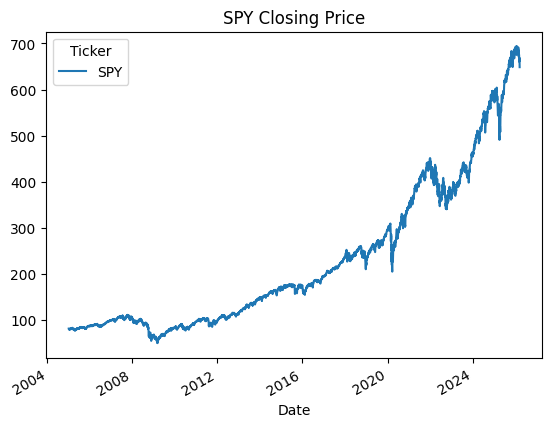

In [10]:
# plot closing price
data["Close"].plot(title="SPY Closing Price")

<Axes: title={'center': 'SPY Returns'}, xlabel='Date', ylabel='Returns'>

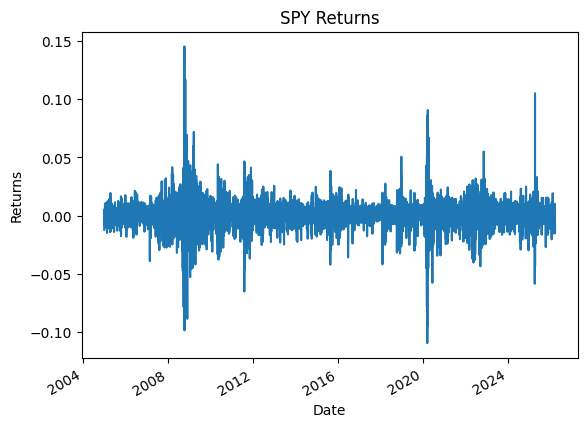

In [11]:
# transform to returns
data["Returns"] = data["Close"].pct_change()
data["Returns"].plot(title="SPY Returns", ylabel="Returns", xlabel="Date")

In general throught the years, the returns oxcillate around 0. Except around 2008, 2024 and 2025 which correspond to unstability periods.

In [12]:
data['Returns'].describe()

count    5336.000000
mean        0.000461
std         0.011969
min        -0.109424
25%        -0.003954
50%         0.000705
75%         0.005798
max         0.145198
Name: Returns, dtype: float64

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

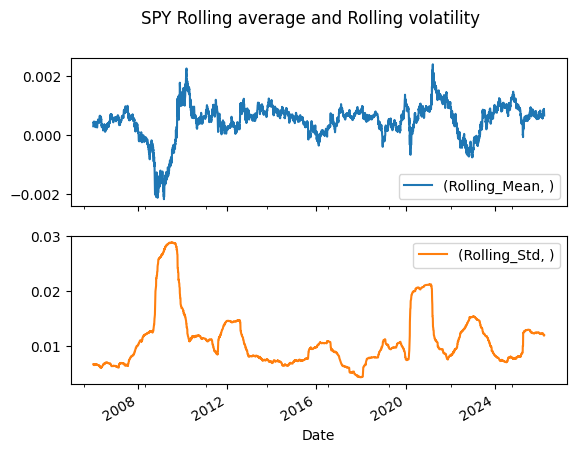

In [13]:
# rolling statistics
data["Rolling_Mean"] = data["Returns"].rolling(window=252).mean()
data["Rolling_Std"] = data["Returns"].rolling(window=252).std()

data[["Rolling_Mean", "Rolling_Std"]].plot(title="SPY Rolling average and Rolling volatility", subplots=True)

The rolling mean exhibits temporary deviations during crisis periods, largely driven by clusters of extreme returns. However, these shifts appear less persistent than the pronounced and sustained changes observed in rolling volatility, suggesting that non-stationarity in returns is primarily variance-driven.

### Distribution sanity checks

<Axes: >

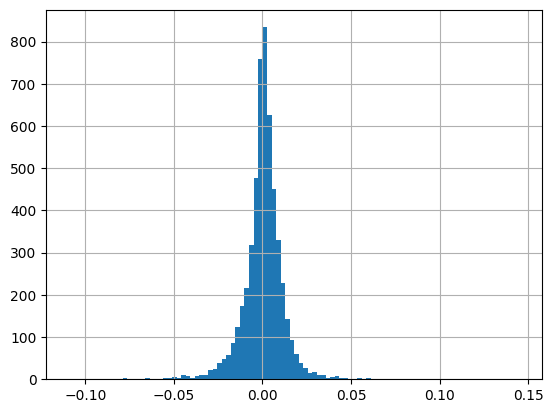

In [14]:
data["Returns"].hist(bins=100)

In [15]:
data["Returns"].skew()

np.float64(0.0004058053556471415)

In [16]:
data["Returns"].kurtosis()

np.float64(15.408659192605272)

<Axes: >

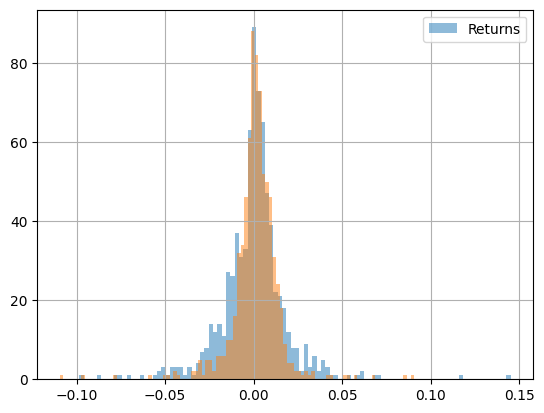

In [17]:
returns_2008 = data.loc["2007":"2009", "Returns"]
returns_2020 = data.loc["2019":"2021", "Returns"]

returns_2008.hist(alpha=0.5, legend=True, bins=100)
returns_2020.hist(alpha=0.5, bins=100)

Return distribution in 2008 is more dispersed and heavy-tailed than in 2024. This indicates higher volatility and tail risk during the 2008 crisis.

SPY returns show variance and distribution changes over time. This motivates distribution shifts detection and model monitoring.

#### Can we detect and characterise changes in the statistical properties of financial returns over time?

we will detect variance and distribution.

Null hypothesis: returns are stationary over time

### Statistical tests: quantify changes